In [137]:
import os
os.chdir("/home/bluefox/NN/NN-Project1")

In [138]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, metrics, optimizers

In [139]:
max_features = 20000
embedding_dim = 128

In [140]:
input1 = layers.Input(shape=(None,), dtype="int64")
emb = layers.Embedding(max_features, embedding_dim)(input1)
emb = layers.SpatialDropout1D(0.5)(emb)

In [141]:
x = layers.Conv1D(128, 7, activation="relu", strides=3)(emb)
x = layers.Conv1D(128, 7, activation="relu", strides=3)(emb)

In [142]:
avg_pool = layers.GlobalAveragePooling1D()(x)
max_pool = layers.GlobalMaxPooling1D()(x)
concat = layers.concatenate([avg_pool, max_pool])

In [143]:
ann = layers.Dense(128, activation="relu")(concat)
ann = layers.Dropout(0.5)(ann)
output1 = layers.Dense(1, activation="sigmoid")(ann)

In [144]:
model = models.Model(inputs=input1, outputs=output1)

In [145]:
model.compile(
    optimizer=optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-3,
        beta_1=0.9,
        beta_2=0.999
    ),
    loss= 'binary_crossentropy',
    metrics=['accuracy',metrics.F1Score(threshold=0.5)]
)

In [146]:
model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_17        │ (None, None, 128) │  2,560,000 │ input_layer_17[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, None, 128) │          0 │ embedding_17[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, None, 128) │    114,816 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv1d_13[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_13[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 128)       │     32,896 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 128)       │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 1)         │        129 │ dropout_23[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,707,841 (10.33 MB)

 Trainable params: 2,707,841 (10.33 MB)

 Non-trainable params: 0 (0.00 B)

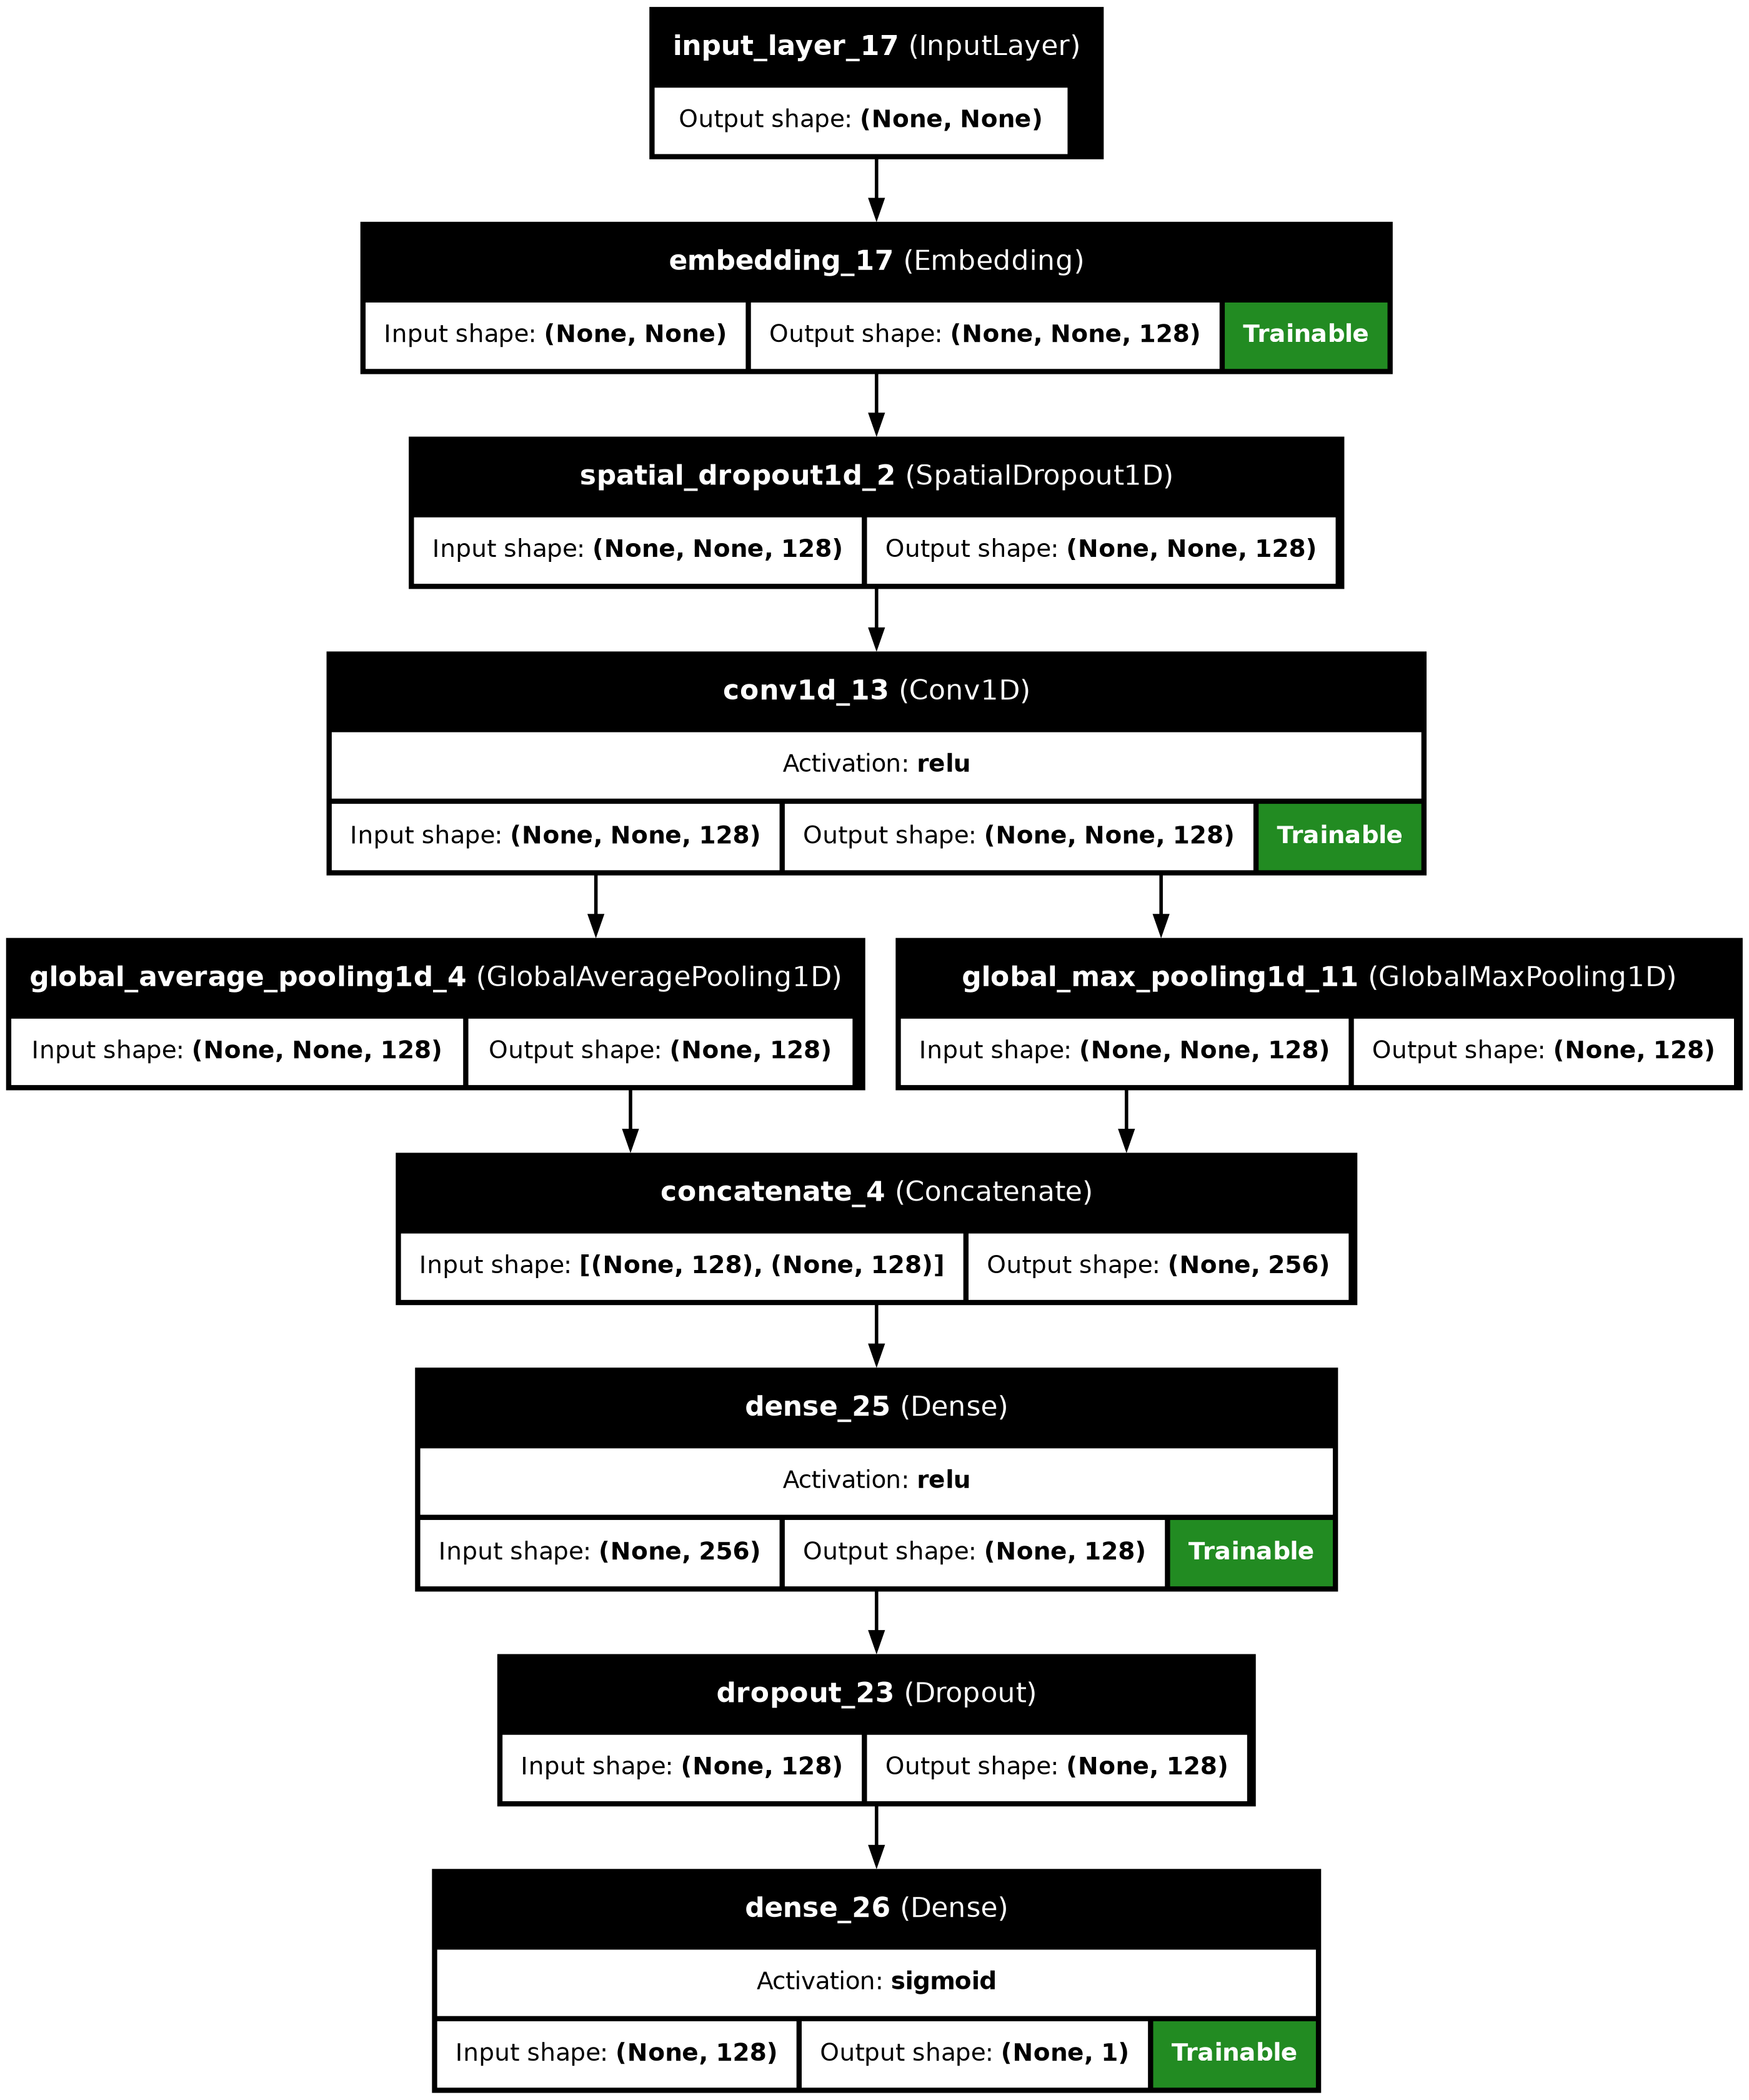

In [147]:
keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    show_trainable=True,
    to_file="results/plots/model_arch.png"
)

In [148]:
model.save("models/architecture/untrained_imdb_model.keras")